## Setting

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 54.8 gigabytes of available RAM

You are using a high-RAM runtime!


In [3]:
!pip install nltk
!pip install -U pandas-profiling
!pip install pydantic
!pip install umap-learn
!pip install factor_analyzer
!pip install typing-extensions --upgrade
!pip install kneed

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.5/357.5 kB 40.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.9/381.9 kB 38.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 13.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.5/679.5 kB 57.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 33.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 89.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 67.8 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27082 sha256=88574a1111d12d6dc8cbf836fb53428d17ad424aed83c6863a7312a09d668d47
  Stored in directory: /root/.cache/pip/wheels/dd/91/29/a79cecb328d01739e64017b6fb9a1ab9d8cb1853098ec5966d
Successfully built htmlmin
  Attempting unin

### Importing Dependencies

In [4]:
import string
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from scipy.sparse import csr_matrix

from sklearn.cluster import SpectralClustering
from sklearn.decomposition import PCA, LatentDirichletAllocation, NMF
from sklearn.feature_selection import chi2, f_classif, SelectKBest
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, TfidfTransformer
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler, RobustScaler, Normalizer, normalize


from wordcloud import WordCloud

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import TreebankWordTokenizer
from nltk.stem import WordNetLemmatizer, PorterStemmer
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

stemmer = PorterStemmer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


### Data Load

In [5]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/pilot_data.csv")
print("초기 Document 수 :", data.shape[0])

초기 Document 수 : 1000


In [6]:
data.columns

Index(['Publication Type', 'Authors', 'Book Authors', 'Book Editors',
       'Book Group Authors', 'Author Full Names', 'Book Author Full Names',
       'Group Authors', 'Article Title', 'Source Title', 'Book Series Title',
       'Book Series Subtitle', 'Language', 'Document Type', 'Conference Title',
       'Conference Date', 'Conference Location', 'Conference Sponsor',
       'Conference Host', 'Author Keywords', 'Keywords Plus', 'Abstract',
       'Addresses', 'Affiliations', 'Reprint Addresses', 'Email Addresses',
       'Researcher Ids', 'ORCIDs', 'Funding Orgs', 'Funding Name Preferred',
       'Funding Text', 'Cited References', 'Cited Reference Count',
       'Times Cited, WoS Core', 'Times Cited, All Databases',
       '180 Day Usage Count', 'Since 2013 Usage Count', 'Publisher',
       'Publisher City', 'Publisher Address', 'ISSN', 'eISSN', 'ISBN',
       'Journal Abbreviation', 'Journal ISO Abbreviation', 'Publication Date',
       'Publication Year', 'Volume', 'Issue', 'Pa

## STEP 1 : Finding the core vecotr space

### Data Cleaning

In [7]:
# delected data where the abstract or title information was missing or was a duplicate

data.dropna(subset=['Abstract', 'Article Title'], inplace=True)
data.drop_duplicates(subset=['Article Title', 'Abstract'], inplace=True)

print("초록, 제목  Null 값 제거 & 중복 제거")
print("Data Cleaning 후 Document 수 :", data.shape[0])

초록, 제목  Null 값 제거 & 중복 제거
Data Cleaning 후 Document 수 : 997


In [9]:
# Data Transformation
def combine_3rd_columns(col_1, col_2, col_3):
    result = col_1

    if not pd.isna(col_2):
        result += " " + str(col_2)

    if not pd.isna(col_3):
        result += " " + str(col_3)

    return result

data["text"] = data.apply(lambda x: combine_3rd_columns(x['Article Title'], x['Abstract'], x['Author Keywords']), axis=1)
data.drop(data[(data['text'] == "")].index, inplace=True) # text가 남아있지 않은 row 삭제

df = data.loc[:, ['text', 'Article Title']]
print("Data Transformation 후 Document 수 :", df.shape[0])

Data Transformation 후 Document 수 : 997


### Data preprocessing

In [8]:
custom_1 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/custom_1.csv")
custom_2 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/custom_2.csv")

custom_nolema = set(custom_1['nolema'])
stop_words = stop_words.union(set(custom_2['Stopwords']))

In [10]:
def preprocess_text(text):

    tokenizer = TreebankWordTokenizer()
    words = tokenizer.tokenize(text)

    original_words = []
    lemmatized_words = []

    words = [token for token in words if token not in string.punctuation]

    for word in words:
        word = word.lower()

        if word not in stop_words and not word.isdigit() :
            if word in custom_nolema:
                lemmatized_words.append(word)
                pass
            else :
                lemma = lemmatizer.lemmatize(word)
                lemmatized_words.append(lemma)

                if word != lemma :
                    original_words.append({word : lemma})

    processed_text = ' '.join([token for token in lemmatized_words])

    return processed_text, original_words

df['processed_data'] = df['text'].apply(preprocess_text)

df[['corpus', 'lemma_pairs']] = pd.DataFrame(df['processed_data'].tolist(), index=df.index)

df.drop(columns=['processed_data', 'text'], inplace=True)
df.head()

,Article Title,corpus,lemma_pairs
0,A Framework of Smart-Home Service for Elderly'...,framework smart-home service elderly 's experi...,"[{'services': 'service'}, {'supports': 'suppor..."
1,Service Provisioning Framework for Digital Sma...,service provisioning framework digital smart h...,"[{'services': 'service'}, {'services': 'servic..."
2,Analysis of Types and Importance of Sensors in...,analysis type importance sensor smart home ser...,"[{'types': 'type'}, {'sensors': 'sensor'}, {'s..."
3,Smart Home Services Based on Event Matching,smart home service event matching smart home i...,"[{'services': 'service'}, {'technologies': 'te..."
4,A Proposal for an Integrated Smart Home Servic...,proposal smart home service platform growing p...,"[{'devices': 'device'}, {'consumers': 'consume..."


##### Customized rules : do not lemmatize “glasses” to “glass”



In [11]:
# find do not lemmatize
check_list = df.loc[:, ['lemma_pairs']]
combined_list = check_list['lemma_pairs'].sum()

def remove_duplicates(lst):
    result = []
    for item in lst:
        if item not in result:
            result.append(item)
    return result

unique_ordered_list  = remove_duplicates(combined_list)
keys, values = [], []

for d in unique_ordered_list:
    for key, value in d.items():
        keys.append(key)
        values.append(value)

checks = pd.DataFrame({'Key': keys, 'Value': values})
checks.drop_duplicates(subset=['Key'], inplace=True)
checks.drop_duplicates(subset=['Value'], inplace=True)

def check_meaning(word):
    singular = wordnet.synsets(word)
    plural = wordnet.synsets(word + 's')

    if singular and plural:
        if singular[0].definition() != plural[0].definition():
            return (True, f"'{word}': {singular[0].definition()}", f"'{word}s': {plural[0].definition()}")

    return (False, None, None)

checks['is_different'], checks['singular_def'], checks['plural_def'] = zip(*checks['Value'].map(check_meaning))
checks[checks['is_different']].to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/customized(not_lemmatize).csv', index=False)

In [204]:
df = df.loc[:, ['corpus', 'Article Title']]
df.drop(df[(df['corpus'] == " ")].index, inplace=True) # corpus 남아있지 않은 row 삭제

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['corpus'])
feature_names = tfidf_vectorizer.get_feature_names_out()

print("전처리 후 Document 갯수:",tfidf_matrix.shape[0])
print("전처리 후 초기 word-feature 갯수:",tfidf_matrix.shape[1])

전처리 후 Document 갯수: 997
전처리 후 초기 word-feature 갯수: 8043


In [205]:
df.head()

,corpus,Article Title
0,framework smart-home service elderly 's experi...,A Framework of Smart-Home Service for Elderly'...
1,service provisioning framework digital smart h...,Service Provisioning Framework for Digital Sma...
2,analysis type importance sensor smart home ser...,Analysis of Types and Importance of Sensors in...
3,smart home service event matching smart home i...,Smart Home Services Based on Event Matching
4,proposal smart home service platform growing p...,A Proposal for an Integrated Smart Home Servic...


### 1. Deciding on the number of keywords to be selected from each item

In [108]:
# visualization function
def plot_keywords(x, y, y_label, title):

    plt.style.use('seaborn-whitegrid')
    plt.figure(figsize=(10,6))

    plt.plot(x, y,  marker='o', color = 'b')

    plt.gca().invert_xaxis()

    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)

    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.gca().set_facecolor('lightgray')
    plt.grid(color='white', linestyle='-', linewidth=1)

    k_formatter = FuncFormatter(lambda x, pos: f'K{x}')
    plt.gca().xaxis.set_major_formatter(k_formatter)

    plt.xticks(range(min(keyword_counts), max(keyword_counts)+1))

    plt.xlabel('Number of selected top keywords from each data')
    plt.ylabel(y_label)

    # for i in [3, 4, 5]:
    #     if i in x:
    #         index = x.index(i)
    #         plt.plot(i, y[index], marker='o', color='y')

    plt.title(title)
    plt.show()

keyword_counts = list(range(20, 1, -1))
tfidf_matrix_transposed = tfidf_matrix.toarray()

##### Metric 1 : Mean of the TF-IDF scores of a word-feature across data

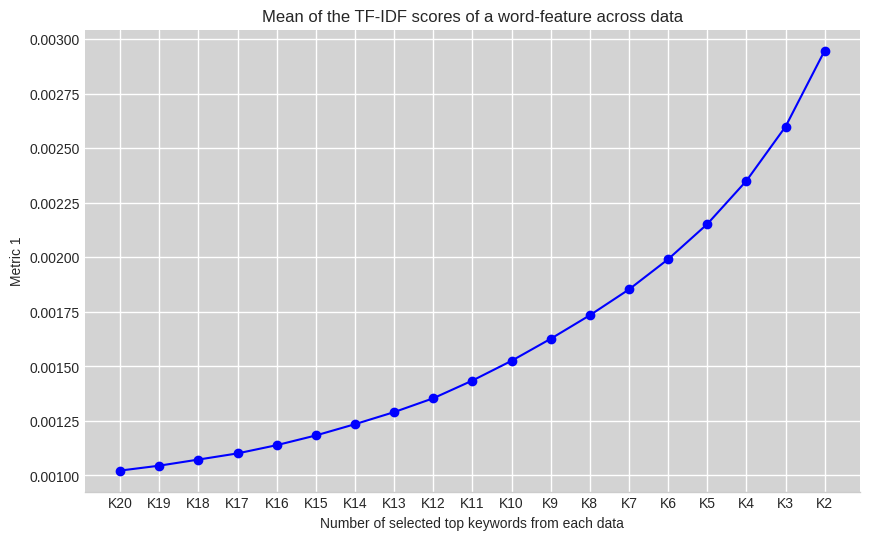

In [109]:
mean_tfidf_scores = []

for count in keyword_counts:
    top_keywords = []

    for doc_idx in range(len(df)):
        tfidf_scores = tfidf_matrix[doc_idx].toarray()[0]
        top_indices = np.argsort(tfidf_scores)[-count:]
        top_keywords.extend([feature_names[idx] for idx in top_indices])
    top_keywords = list(set(top_keywords))

    keyword_indices = [np.where(np.array(feature_names) == keyword)[0][0] for keyword in top_keywords]
    keyword_tfidf_scores = tfidf_matrix[:, keyword_indices].toarray()

    # TF-IDF score 평균 계산
    mean_tfidf_score = np.mean(keyword_tfidf_scores)
    mean_tfidf_scores.append(mean_tfidf_score)

plot_keywords(keyword_counts, mean_tfidf_scores, 'Metric 1',  'Mean of the TF-IDF scores of a word-feature across data')

##### Metric 2 : Mean of the cosine similarities of a word-feature to other features

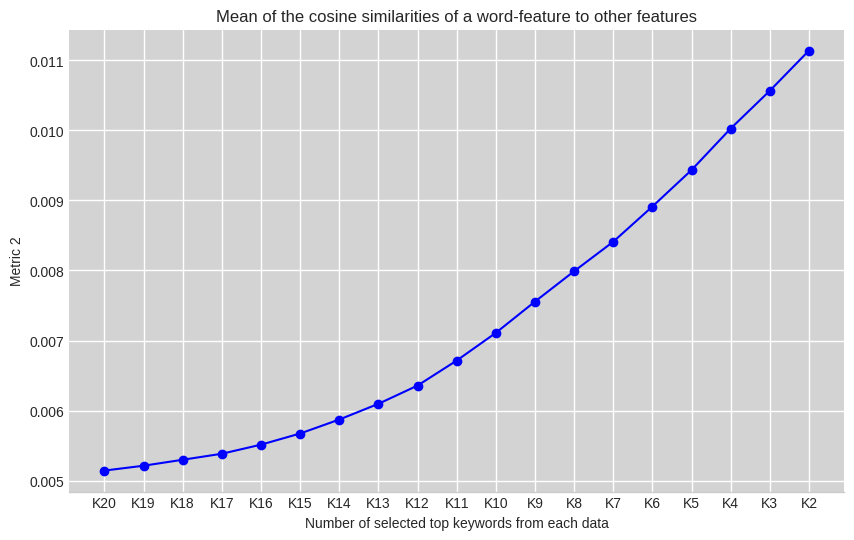

In [179]:
mean_cosine_similarities = []

for num_keywords in keyword_counts:
    top_keywords = []

    for doc_idx in range(len(df)):
        tfidf_scores = tfidf_matrix[doc_idx].toarray()[0]
        top_indices = np.argsort(tfidf_scores)[-num_keywords:]
        top_keywords.extend([feature_names[idx] for idx in top_indices])

    top_keywords = list(set(top_keywords))

    keyword_indices = [np.where(np.array(feature_names) == keyword)[0][0] for keyword in top_keywords]
    keyword_matrix = tfidf_matrix[:, keyword_indices].T
    cosine_similarities = cosine_similarity(keyword_matrix)

    mean_cosine_similarity = np.mean(cosine_similarities)
    mean_cosine_similarities.append(mean_cosine_similarity)

plot_keywords(keyword_counts, mean_cosine_similarities,'Metric 2', 'Mean of the cosine similarities of a word-feature to other features')

##### Metric 3 : Cosine similarity between a word-feature and the centroid of features

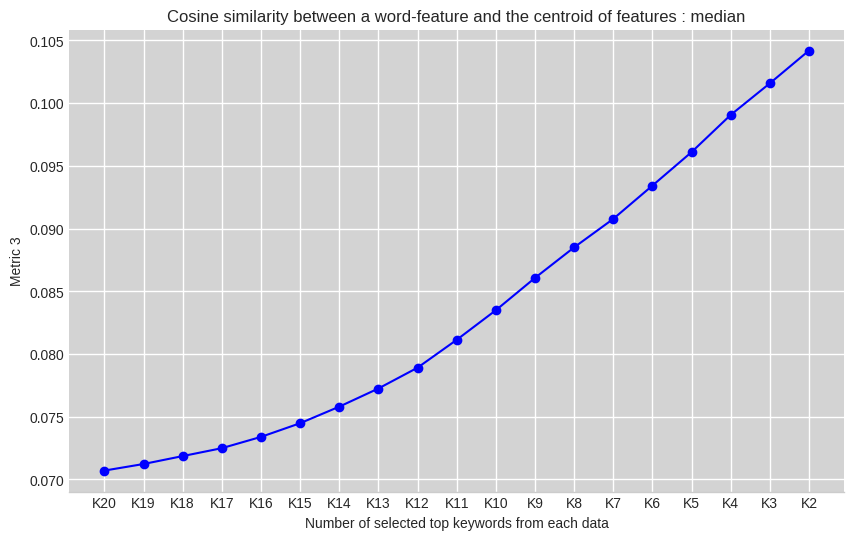

In [164]:
median_cosine_similarities = []

for count in keyword_counts:
    top_keywords = []

    for doc_idx in range(len(df)):
        tfidf_scores = tfidf_matrix[doc_idx].toarray()[0]
        top_indices = np.argsort(tfidf_scores)[-count:]
        top_keywords.extend([feature_names[idx] for idx in top_indices])

    top_keywords = list(set(top_keywords))

    keyword_indices = [np.where(np.array(feature_names) == keyword)[0][0] for keyword in top_keywords]
    keyword_matrix = tfidf_matrix[:, keyword_indices]

    keyword_matrix = keyword_matrix.T.toarray()

    centroid = np.mean(keyword_matrix, axis=0)
    centroid = np.asarray(centroid).reshape(1, -1)

    cosine_similarities = []

    for idx in range(keyword_matrix.shape[0]):
        word_vector = keyword_matrix[idx, :]
        word_vector = np.asarray(word_vector).reshape(1, -1)
        cosine_similarity_value = cosine_similarity(word_vector, centroid)
        cosine_similarities.append(cosine_similarity_value[0][0])


    mean_cosine_similarity = np.mean(cosine_similarities)
    median_cosine_similarities.append(mean_cosine_similarity)

plot_keywords(keyword_counts, median_cosine_similarities, "Metric 3", "Cosine similarity between a word-feature and the centroid of features : median")

##### Metric 4 : Mean of the dot product scores of a word-feature to other features

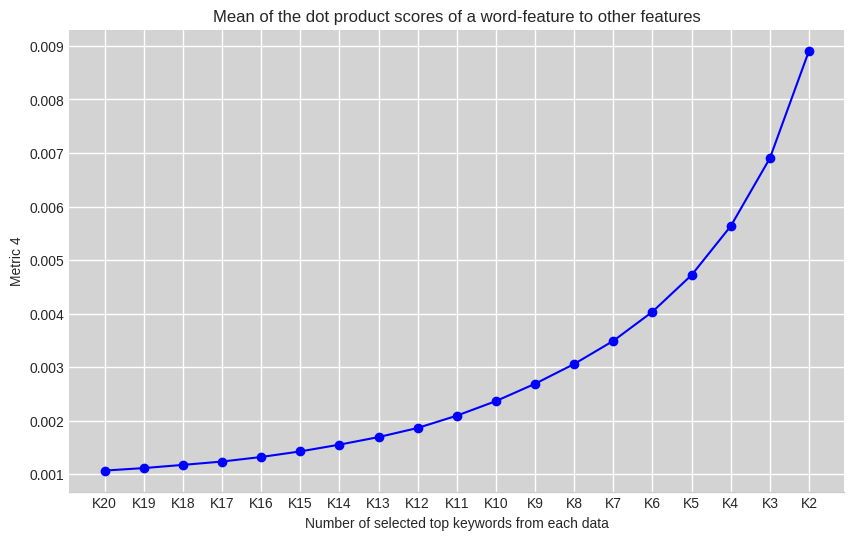

In [165]:
mean_dot_product_scores = []

for count in keyword_counts:
    top_keywords = []

    for doc_idx in range(len(df)):
        tfidf_scores = tfidf_matrix[doc_idx].toarray()[0]
        top_indices = np.argsort(tfidf_scores)[-count:]
        top_keywords.extend([feature_names[idx] for idx in top_indices])

    top_keywords = list(set(top_keywords))

    keyword_indices = [np.where(np.array(feature_names) == keyword)[0][0] for keyword in top_keywords]
    keyword_tfidf_scores = tfidf_matrix[:, keyword_indices].toarray()
    dot_product_scores = np.dot(keyword_tfidf_scores.T, keyword_tfidf_scores)

    mean_dot_product_score = np.mean(dot_product_scores)
    mean_dot_product_scores.append(mean_dot_product_score)

plot_keywords(keyword_counts, mean_dot_product_scores,"Metric 4", "Mean of the dot product scores of a word-feature to other features")

##### Metric 5 : LDA score of a word-feature for the single topic of entire data set

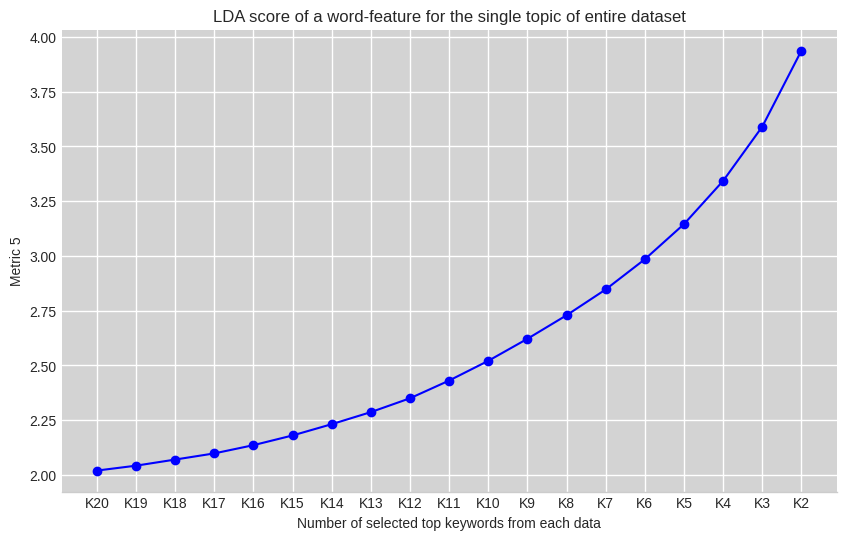

In [177]:
mean_lda_scores = []

for count in keyword_counts:
    top_keywords = []

    for doc_idx in range(len(df)):
        tfidf_scores = tfidf_matrix[doc_idx].toarray()[0]
        top_indices = np.argsort(tfidf_scores)[-count:]
        top_keywords.extend([feature_names[idx] for idx in top_indices])

    top_keywords = list(set(top_keywords))
    keyword_indices = [np.where(np.array(feature_names) == keyword)[0][0] for keyword in top_keywords]
    keyword_matrix = tfidf_matrix[:, keyword_indices].toarray()

    num_topics = 1
    lda_model = LatentDirichletAllocation(n_components=num_topics)
    lda_model.fit(keyword_matrix)

    lda_scores = lda_model.components_

    mean_lda_score = np.mean(lda_scores)
    mean_lda_scores.append(mean_lda_score)

plot_keywords(keyword_counts, mean_lda_scores,"Metric 5", "LDA score of a word-feature for the single topic of entire dataset")

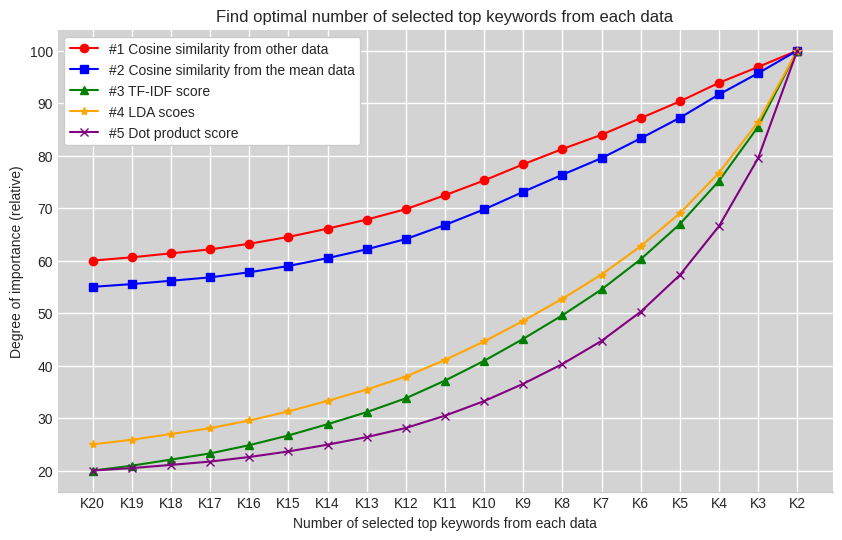

In [180]:
metric1_values = median_cosine_similarities
metric2_values = mean_cosine_similarities
metric3_values = mean_tfidf_scores
metric4_values = mean_lda_scores
metric5_values = mean_dot_product_scores

metric1_normalized = (metric1_values - np.min(metric1_values)) / (np.max(metric1_values) - np.min(metric1_values)) * 40 + 60
metric2_normalized = (metric2_values - np.min(metric2_values)) / (np.max(metric2_values) - np.min(metric2_values)) * 45 + 55
metric3_normalized = (metric3_values - np.min(metric3_values)) / (np.max(metric3_values) - np.min(metric3_values)) * 80 + 20
metric4_normalized = (metric4_values - np.min(metric4_values)) / (np.max(metric4_values) - np.min(metric4_values)) * 75 + 25
metric5_normalized = (metric5_values - np.min(metric5_values)) / (np.max(metric5_values) - np.min(metric5_values)) * 80 + 20

plt.style.use('seaborn-whitegrid')
plt.figure(figsize=(10,6))

plt.gca().invert_xaxis()

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.gca().set_facecolor('lightgray')

plt.xticks(range(min(keyword_counts), max(keyword_counts)+1))

k_formatter = FuncFormatter(lambda x, pos: f'K{x}')

plt.gca().xaxis.set_major_formatter(k_formatter)
plt.grid(color='white', linestyle='-', linewidth=1)
plt.xlabel('Number of selected top keywords from each data')
plt.ylabel('Degree of importance (relative)')

plt.plot(keyword_counts, metric1_normalized, marker='o', label='#1 Cosine similarity from other data', color='red')
plt.plot(keyword_counts, metric2_normalized, marker='s', label='#2 Cosine similarity from the mean data', color='blue')
plt.plot(keyword_counts, metric3_normalized, marker='^', label='#3 TF-IDF score', color='green')
plt.plot(keyword_counts, metric4_normalized, marker='*', label='#4 LDA scoes', color='orange')
plt.plot(keyword_counts, metric5_normalized, marker='x', label='#5 Dot product score', color='purple')

plt.xlabel('Number of selected top keywords from each data')
plt.ylabel('Degree of importance (relative)')
plt.title('Find optimal number of selected top keywords from each data')
plt.legend(frameon = True, framealpha=1)

plt.show()

##### Result

In [206]:
# Items 당 상위 4개의 단어 선택 - Type 3 제거
top_keywords_per_document = []
feature_names = tfidf_vectorizer.get_feature_names_out()

for i in range(len(df)):
    tfidf_scores = zip(feature_names, tfidf_matrix[i].toarray()[0])
    sorted_tfidf_scores = sorted(tfidf_scores,key=lambda x: x[1], reverse=True)

    top_keywords_per_document.append([keyword for keyword,_ in sorted_tfidf_scores[:5]])

# 전체 데이터셋에서 적어도 2번 이상 나온 키워드 추출하기 - Type 1 제거
all_keywords=[keyword for document in top_keywords_per_document for keyword in document]
selected_keywords=list(set(keyword for keyword in all_keywords if all_keywords.count(keyword) >=2))

vectorizer = TfidfVectorizer(vocabulary=selected_keywords)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])

print("현재 Document 갯수:",tfidf_matrix.shape[0])
print("현재 word-feature 갯수:",tfidf_matrix.shape[1])

현재 Document 갯수: 997
현재 word-feature 갯수: 676


### 2. Word_featuring Clustering based on Gaussian mixture model (GMM)

In [207]:
vectorizer = TfidfVectorizer(vocabulary=selected_keywords)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])
feature_names = vectorizer.get_feature_names_out()

tfidf_matrix_transposed = tfidf_matrix.T.toarray()

In [208]:
from collections import defaultdict

# memory issue
tfidf_matrix = tfidf_matrix.astype('float32')
tfidf_matrix_transposed = tfidf_matrix.T.toarray()

union_keywords_set = None
intersection_keywords_set = None

keyword_frequency = defaultdict(int)

# GMM based Clustering
for i in range(10):

    gmm = GaussianMixture(n_components=100, covariance_type='diag')
    gmm.fit(tfidf_matrix_transposed)

    cluster_labels = gmm.predict(tfidf_matrix_transposed)

    df_clustered_keywords = pd.DataFrame(feature_names, columns=['keyword'])
    df_clustered_keywords['cluster'] = cluster_labels

    cluster_counts = df_clustered_keywords['cluster'].value_counts()
    max_data_pointer_cluster_labels = cluster_counts.nlargest(1).index.tolist()
    max_data_pointer_cluster = df_clustered_keywords[df_clustered_keywords['cluster'].isin(max_data_pointer_cluster_labels)]['keyword'].values.tolist()

    for keyword in max_data_pointer_cluster:
        keyword_frequency[keyword] += 1

    print((df_clustered_keywords['cluster'].value_counts()))
    print(f"{i + 1}번째 시행 클러스터 속 데이터 갯수:", len(max_data_pointer_cluster))

    if i == 0:
        union_keywords_set=set(max_data_pointer_cluster)
        intersection_keywords_set=set(max_data_pointer_cluster)

    else:
        union_keywords_set=union_keywords_set.union(set(max_data_pointer_cluster))
        intersection_keywords_set=intersection_keywords_set.intersection(set(max_data_pointer_cluster))

extract_union_list = list(union_keywords_set)
extract_intersection_list = list(intersection_keywords_set)

select_union_list = [keyword for keyword in selected_keywords if keyword not in extract_union_list]
select_intersection_list = [keyword for keyword in selected_keywords if keyword not in extract_intersection_list]


print("전체 키워드 갯수", len(selected_keywords))
print(" ")
print("합집합인 경우 Type 2", len(select_union_list))
print("합집합인 경우 Type 1 & 3 :", len(extract_union_list))
print(" ")
print("교집합인 경우 Type 2", len(select_intersection_list))
print("교집합인 경우 Type 1 & 3 :", len(extract_intersection_list))

69    489
22     47
18     15
31      7
96      6
     ... 
6       1
15      1
53      1
47      1
14      1
Name: cluster, Length: 100, dtype: int64
1번째 시행 클러스터 속 데이터 갯수: 489
53    436
13    137
62      2
1       2
97      2
     ... 
52      1
43      1
17      1
74      1
15      1
Name: cluster, Length: 100, dtype: int64
2번째 시행 클러스터 속 데이터 갯수: 436
69    265
94    119
40     80
56     34
78     33
     ... 
13      1
49      1
67      1
35      1
9       1
Name: cluster, Length: 100, dtype: int64
3번째 시행 클러스터 속 데이터 갯수: 265
55    318
38     85
27     62
1      45
97     40
     ... 
69      1
25      1
29      1
7       1
21      1
Name: cluster, Length: 100, dtype: int64
4번째 시행 클러스터 속 데이터 갯수: 318
8     555
2      10
85      5
3       4
98      3
     ... 
70      1
27      1
26      1
87      1
20      1
Name: cluster, Length: 100, dtype: int64
5번째 시행 클러스터 속 데이터 갯수: 555
23    539
6      13
15     10
13     10
5       4
     ... 
77      1
52      1
76      1
14      1
26      1
Name:

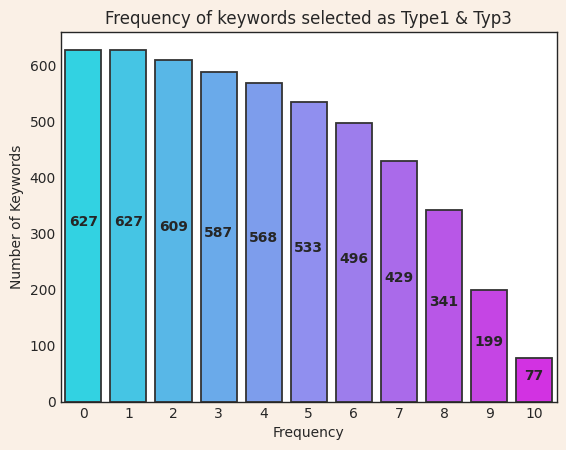

In [209]:
import seaborn as sns

x = [j for j in range(0, 11)]
counts = []

fig = plt.figure(facecolor='linen')

for i in range(0, 11):
    counts.append(len([k for k, v in keyword_frequency.items() if v >= i]))

sns.set_style("white")
palette = sns.color_palette("cool", len(x))

barplot = sns.barplot(x = x, y=counts, palette=palette, linewidth=1.3, edgecolor=".2")

for idx, val in enumerate(counts):
    barplot.text(idx, val/2, val, ha='center', weight = 'bold')


plt.title('Frequency of keywords selected as Type1 & Typ3')
plt.xlabel('Frequency')
plt.ylabel('Number of Keywords')
plt.show()

In [210]:
extract_intersection_list = [k for k, v in keyword_frequency.items() if v >= 9]
select_keywords_list = [keyword for keyword in selected_keywords if keyword not in extract_intersection_list]

In [195]:
select_keywords_list = select_intersection_list
extract_keywords_list = extract_intersection_list

In [211]:
vectorizer = TfidfVectorizer(vocabulary=select_keywords_list)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])
print("Core-word feature Document 갯수:",tfidf_matrix.shape[0])
print("Core-word feature Document word-feature 갯수:",tfidf_matrix.shape[1])

Core-word feature Document 갯수: 997
Core-word feature Document word-feature 갯수: 477


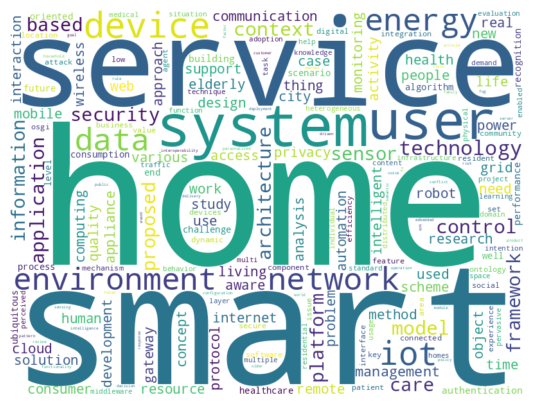

In [212]:
dtm_array = tfidf_matrix.toarray()
dtm_df = pd.DataFrame(dtm_array, columns=select_keywords_list)
average_tfidf = dtm_df.mean()

average_tfidf_dict = average_tfidf.to_dict()

wordcloud = WordCloud(background_color='white', width=800, height=600)
wordcloud.generate_from_frequencies(average_tfidf_dict)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [ ]:
# Stopword list를 생성하기 위한 Check 지표
checking_1= pd.DataFrame(select_keywords_list, columns = ['keyword'])
checking_1.to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/final_select_keyword.csv', index=False)

checking_2 = pd.DataFrame(extract_keywords_list, columns = ['keyword'])
checking_2.to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/stopwords.csv', index=False)

### Eliminated outliers by calculating the cosine similarities(Entire dataset)

In [ ]:
# perform on entire dataset
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out(), index=df.index)

cosine_sim = cosine_similarity(tfidf_df) - np.eye(tfidf_df.shape[0])
mean_cosine_sim = np.mean(cosine_sim, axis=1)

df_cosine_sim = pd.DataFrame(mean_cosine_sim, columns=['Mean Cosine Similarity'], index=df.index)
df_sorted = df_cosine_sim.sort_values(by='Mean Cosine Similarity')

bottom_100_indices_and_values = df_sorted.head(100)

bottom_100_titles = df.loc[bottom_100_indices_and_values.index, 'Article Title']
bottom_100_titles.to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/Eliminated_documents.csv', index=False)

# del document
print("최종 선정 Document 갯수:",tfidf_matrix.shape[0])
print("최종 선정 word-feature 갯수:",tfidf_matrix.shape[1])

최종 선정 Document 갯수: 4716
최종 선정 word-feature 갯수: 966


## STEP 2 : Descriptive analysis

### Word analysis

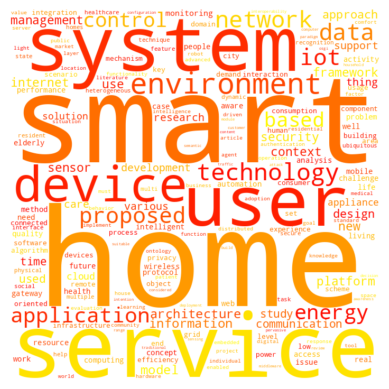

In [214]:
tfidf = tfidf_matrix
tfidf_array = tfidf.toarray()

tfidf_means = np.mean(tfidf_array, axis=0).reshape(-1, 1)
cosine_sim = cosine_similarity(tfidf_array.T)
cosine_means = np.mean(cosine_sim, axis=0).reshape(-1, 1)

# 중심점 계산
centroid_features = np.mean(tfidf_array.T, axis=0)
cosine_similarities = cosine_similarity(tfidf_array.T, centroid_features.reshape(1, -1))

dot_product = tfidf_array.T.dot(tfidf_array)
dot_product_means = np.mean(dot_product, axis=0).reshape(-1, 1)

lda_model = LatentDirichletAllocation(n_components=1)
lda_model.fit(tfidf_array)
lda_scores = lda_model.components_[0].reshape(-1, 1)

# 스케일링
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(np.hstack([tfidf_means, cosine_means, cosine_similarities, dot_product_means, lda_scores]))

# 스케일링된 값들을 합침
keyword_values = np.sum(scaled_values, axis=1)

# NaN 값이 있는지 확인
if np.isnan(keyword_values).any():
    # NaN 값을 0으로 채움
    keyword_values = np.nan_to_num(keyword_values)

# 워드 클라우드 그리기
wordcloud = WordCloud(background_color ='white', colormap='autumn',
                      width = 700, height = 700, random_state = 43,
                      prefer_horizontal = True).generate_from_frequencies(dict(zip(vectorizer.get_feature_names_out(), keyword_values)))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

### find Top 10 Research Areas and Journals Related to Smart Home Service

### Word association rule mining

## STEP 3 : Unsupervised machine learning

### Principal component analysis(PCA)

In [215]:
vectorizer = TfidfVectorizer(vocabulary=select_keywords_list)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])

Number of components for 95% variance: 311


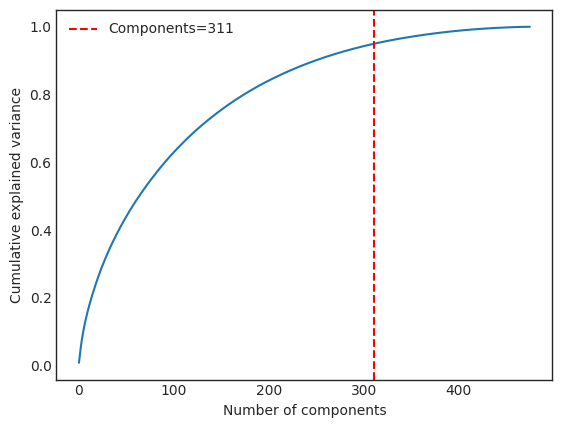

In [216]:
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import numpy as np

X = tfidf_matrix

svd = TruncatedSVD(n_components=X.shape[1]-1)
svd.fit(X)

cumulative_explained_variance = np.cumsum(svd.explained_variance_ratio_)

n_components = np.where(cumulative_explained_variance > 0.95)[0][0]

print(f"Number of components for 95% variance: {n_components}")

plt.plot(cumulative_explained_variance)
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.axvline(x=n_components, color='r', linestyle='--', label=f'Components={n_components}')
plt.legend()
plt.show()

### Spectral Clustering

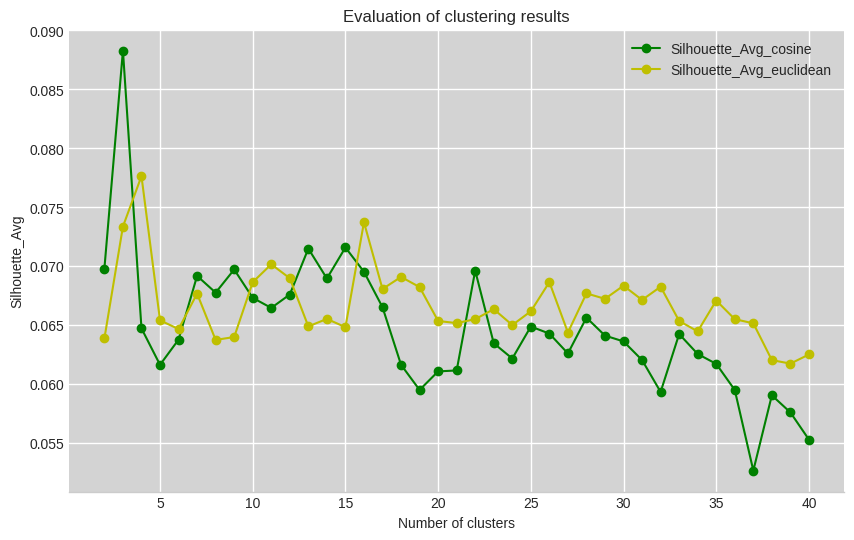

In [218]:
# find optimal cluster numbers
svd = TruncatedSVD(n_components=n_components)
tfidf_matrix_svd = svd.fit_transform(tfidf_matrix)

metrics = ['cosine', 'euclidean']
cluster_range = range(2, 41)

results = {}

for metric in metrics:
    results[metric] = []

    if metric == 'cosine':
        affinity = 'precomputed'
        sim_matrix = cosine_similarity(tfidf_matrix_svd)

    elif metric == 'euclidean':
        affinity = 'precomputed'
        distance_matrix = euclidean_distances(tfidf_matrix_svd)
        sigma = np.mean(distance_matrix)
        sim_matrix = np.exp(-distance_matrix ** 2 / (2. * sigma ** 2))


    for n_clusters in cluster_range:
        silhouette_avg_list = []

        # Spectral Clustering 실행 (10번 반복)
        for _ in range(10):
            sc = SpectralClustering(n_clusters=n_clusters, affinity = affinity, assign_labels = 'kmeans', random_state = 42).fit(sim_matrix)
            labels=sc.labels_

            silhouette_avg_list.append(silhouette_score(sim_matrix, labels))

        results[metric].append(np.mean(silhouette_avg_list))

plt.style.use('seaborn-whitegrid')
plt.figure(figsize=(10,6))

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.gca().set_facecolor('lightgray')
plt.grid(color='white', linestyle='-', linewidth=1)

for metric in metrics:

    if metric == 'cosine':
        color = 'g'
    elif metric == 'euclidean':
        color = 'y'

    plt.plot(cluster_range, results[metric], label=f'Silhouette_Avg_{metric}', marker='o', color = color)

plt.title('Evaluation of clustering results')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette_Avg')
plt.legend()
plt.show()

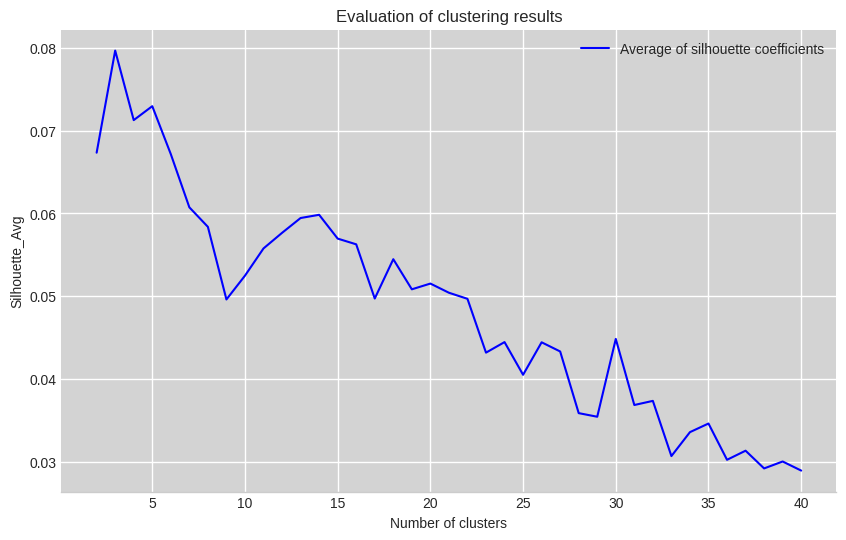

In [ ]:
plt.style.use('seaborn-whitegrid')
plt.figure(figsize=(10,6))

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.gca().set_facecolor('lightgray')
plt.grid(color='white', linestyle='-', linewidth=1)

# for metric in metrics:

#     if metric == 'cosine':
#         color = 'g'
#     elif metric == 'euclidean':
#         color = 'y'

plt.plot(cluster_range, results['euclidean'], label=f'Average of silhouette coefficients', color = 'b')

plt.title('Evaluation of clustering results')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette_Avg')
plt.legend()
plt.show()

## STEP 4 : Interpreting the clusters

### Simple analysis (F-values, chi_squared)

In [ ]:
n_clusters = 14

vectorizer = TfidfVectorizer(vocabulary=select_keywords_list)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])

# svd = TruncatedSVD(n_components=n_components)
# tfidf_matrix_svd = svd.fit_transform(tfidf_matrix)

affinity = 'precomputed'
sim_matrix = cosine_similarity(tfidf_matrix)

clustering = SpectralClustering(n_clusters=n_clusters, affinity = affinity).fit(sim_matrix)

labels = clustering.labels_

kbest_chi2 = SelectKBest(score_func=chi2, k=100)
kbest_chi2.fit(tfidf_matrix, labels)
word_features_chi2 = np.array(kbest_chi2.get_support(indices=True))

kbest_f = SelectKBest(score_func=f_classif, k=100)
kbest_f.fit(tfidf_matrix, labels)
word_features_f = np.array(kbest_f.get_support(indices=True))

word_features = set(word_features_chi2) & set(word_features_f)
print("Top 100 Word-Features with Clear Differences among Clusters:")

feature_names = vectorizer.get_feature_names_out()
for feature_index in word_features:
    print(feature_names[feature_index])

Top 100 Word-Features with Clear Differences among Clusters:
elderly
wireless
battery
intervention
power
patient
lightweight
sensor
card
consumption
robotic
attack
caregiver
chronic
child
electricity
protocol
solar
charging
disease
roaming
network
agreement
security
aware
mutual
management
cloud
19
healthcare
robot
energy
living
vehicle
robotics
demand
urban
context
peak
ev
authentication
renewable
assistive
medical
community
anonymity
authenticated
mother
node
older
internet
load
mitii
care
grid
ontology
health
key
electric
nursing
dr
adult
password
device
thing
people
activity
recognition
telemedicine
user
city
appliance
scheme
edge
daily
family
parenting
blood
secure
iot
human
clinical


### Topic modeling(NMF & LDA)

In [ ]:
from collections import Counter

cluster_counts = Counter(labels)

for cluster, count in cluster_counts.items():
    print(f"클러스터 {cluster}: {count}개의 문서")

클러스터 1: 1277개의 문서
클러스터 8: 737개의 문서
클러스터 3: 291개의 문서
클러스터 7: 113개의 문서
클러스터 0: 442개의 문서
클러스터 12: 258개의 문서
클러스터 11: 217개의 문서
클러스터 13: 264개의 문서
클러스터 2: 276개의 문서
클러스터 4: 154개의 문서
클러스터 10: 230개의 문서
클러스터 5: 33개의 문서
클러스터 6: 310개의 문서
클러스터 9: 114개의 문서


In [ ]:
n_topics = 1

nmf = NMF(n_components=n_topics, random_state=0)
nmf_topics = []

for i in range(n_clusters):
    cluster_data = X[labels == i]

    nmf.fit(cluster_data)
    nmf_topic_words = nmf.components_.argsort()[:, ::-1]
    nmf_topics.append(nmf_topic_words)

lda = LatentDirichletAllocation(n_components=n_topics, random_state=0)
lda_topics = []

for i in range(n_clusters):
    cluster_data = X[labels == i]

    lda.fit(cluster_data)
    lda_topic_words = lda.components_.argsort()[:, ::-1]
    lda_topics.append(lda_topic_words)

n_top_words = 20  # 상위 키워드 수를 설정합니다. 원하는 수로 변경 가능합니다.

for i in range(n_clusters):
    print("Cluster %d:" % i)

    for j in range(n_topics):
        print("NMF Topic %d:" % j, [vectorizer.get_feature_names_out()[index] for index in nmf_topics[i][j, :n_top_words]])
        print("LDA Topic %d:" % j, [vectorizer.get_feature_names_out()[index] for index in lda_topics[i][j, :n_top_words]])
        print("  ")

Cluster 0:
NMF Topic 0: ['network', 'wireless', 'sensor', 'home', 'smart', 'communication', 'service', 'system', 'data', 'node', 'protocol', 'traffic', 'gateway', 'application', 'power', 'device', 'security', 'technology', 'grid', 'proposed']
LDA Topic 0: ['network', 'wireless', 'sensor', 'home', 'smart', 'communication', 'service', 'system', 'data', 'node', 'protocol', 'traffic', 'application', 'power', 'device', 'gateway', 'proposed', 'technology', 'security', 'm2m']
  
Cluster 1:
NMF Topic 0: ['home', 'smart', 'system', 'user', 'service', 'device', 'environment', 'technology', 'control', 'application', 'appliance', 'design', 'data', 'automation', 'information', 'sensor', 'model', 'using', 'based', 'framework']
LDA Topic 0: ['home', 'smart', 'system', 'user', 'service', 'device', 'environment', 'technology', 'control', 'application', 'design', 'appliance', 'data', 'information', 'based', 'model', 'sensor', 'automation', 'using', 'intelligent']
  
Cluster 2:
NMF Topic 0: ['activity', 


### Visualization(Longabaugh, 2012)

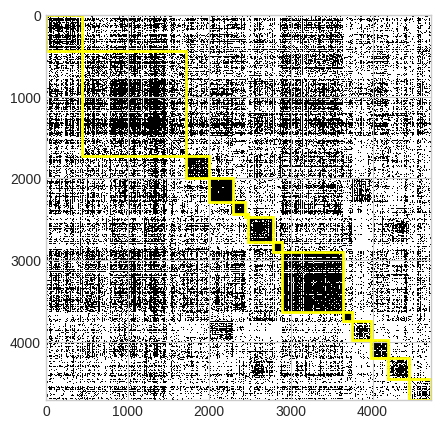

In [ ]:
import networkx as nx
from matplotlib import pyplot, patches

cos_sim = cosine_similarity(tfidf_matrix)
mean_sim = np.mean(cos_sim)
binary_adj_matrix = np.where(cos_sim >= mean_sim, 1, 0)

node_order = np.argsort(labels)
sorted_binary_adj_matrix = binary_adj_matrix[node_order, :][:, node_order]

def draw_adjacency_matrix(G, node_order=None, partitions=[], colors=[]):
    """
    - G is a netorkx graph
    - node_order (optional) is a list of nodes, where each node in G
          appears exactly once
    - partitions is a list of node lists, where each node in G appears
          in exactly one node list
    - colors is a list of strings indicating what color each
          partition should be
    If partitions is specified, the same number of colors needs to be
    specified.
    """
    adjacency_matrix = nx.to_numpy_array(G, dtype=np.bool, nodelist=node_order)

    #Plot adjacency matrix in toned-down black and white
    fig = pyplot.figure(figsize=(5, 5)) # in inches
    pyplot.imshow(adjacency_matrix,
                  cmap="Greys",
                  interpolation="none")

    # The rest is just if you have sorted nodes by a partition and want to
    # highlight the module boundaries
    assert len(partitions) == len(colors)
    ax = pyplot.gca()
    current_idx = 0
    for partition, color in zip(partitions, colors):
        ax.add_patch(patches.Rectangle((current_idx, current_idx),
                                          len(partition), # Width
                                          len(partition), # Height
                                          facecolor="none",
                                          edgecolor=color,
                                          linewidth=2))
        current_idx += len(partition)

G = nx.from_numpy_array(sorted_binary_adj_matrix)

partitions = []
for i in range(n_clusters):
    partitions.append([idx for idx, cluster in enumerate(labels) if cluster == i])

colors = ['#FFFF00' for _ in range(n_clusters)]
draw_adjacency_matrix(G, partitions=partitions, colors=colors)

### Network analysis

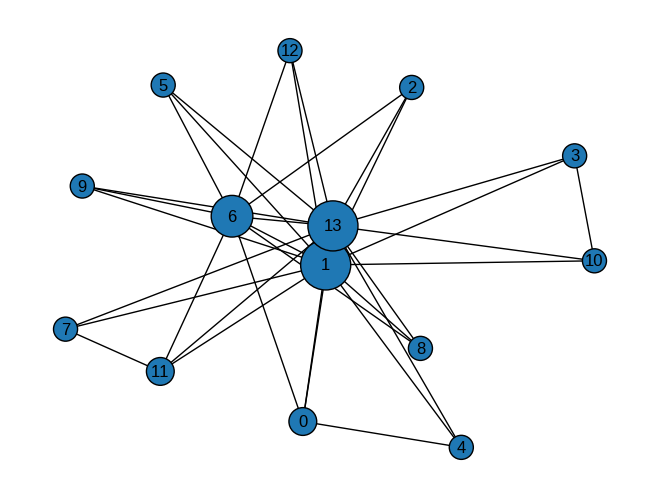

In [ ]:
from operator import itemgetter
import matplotlib.cm as cm

centroids = []
for i in range(n_clusters):
    members = X[clustering.labels_ == i]
    centroid = np.median(members.toarray(), axis=0)
    centroids.append(centroid)

similarity_matrix = cosine_similarity(centroids)

# 각 클러스터에서 가장 유사한 3개의 클러스터를 찾기
top_clusters = {}
for i in range(n_clusters):
    similar_clusters = sorted(list(enumerate(similarity_matrix[i])), key=itemgetter(1), reverse=True)[1:4]
    top_clusters[i] = [idx for idx, similarity in similar_clusters]

G = nx.Graph()
for cluster, neighbors in top_clusters.items():
    for neighbor in neighbors:
        G.add_edge(cluster, neighbor)

sizes = [G.degree(node) * 100 for node in G]
colors = cm.rainbow(np.linspace(0, 1, n_clusters))
node_colors = [colors[i] for i in range(n_clusters)]

nx.draw(G, with_labels=True, node_size=sizes, edgecolors = 'black')